In [19]:
from google.colab import drive
drive.mount('/content/drive')

!ls /content/drive/MyDrive
!unzip -q /content/drive/MyDrive/dataset_blood_group.zip -d /content/
!ls /content
!ls /content/dataset_blood_group

import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'2 sem fees.pdf'
'43 new .pdf'
 55555555.pdf
'Assignment '
 basicimplementationofqueue.cpp
 blood_group_models
'Colab Notebooks'
'Copy of Java Cloud Notes Links.rtf'
 dataset_blood_group.zip
'didi admit card.pdf'
'Document from Shivam Verma_116.pdf'
'examinationservices.nic.in ExamSysCTET downloadAdmitCard frmAuthforCity.aspx?appformid=102012412'
'Gmail - For fees payment of 2nd semester.pdf'
'mess fess 27500'
 notes_DSA_Jain_bhai.gdoc
 problembasedonqueue.cpp
 Reader
'Scholarship '
'SHIVAM_VERMA_116(2MB).pdf'
 ssssss.pdf
replace /content/dataset_blood_group/A+/cluster_0_1001.BMP? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
dataset_blood_group  drive  sample_data
A+  A-	AB+  AB-  B+  B-  O+  O-
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
import os
import glob
import cv2
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import albumentations as A

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Add, Input
from tensorflow.keras.utils import Sequence, to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [21]:
file_path = '/content/dataset_blood_group'

filepaths = list(glob.glob(file_path + '/**/*.*'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

data = pd.DataFrame({
    'Filepath': filepaths,
    'Label': labels
}).sample(frac=1).reset_index(drop=True)

print(data.head())
print(f"\nTotal samples: {len(data)}")
print(f"Classes: {data['Label'].unique()}")

                                            Filepath Label
0  /content/dataset_blood_group/O-/cluster_7_1945...    O-
1  /content/dataset_blood_group/B-/cluster_3_5806...    B-
2  /content/dataset_blood_group/AB-/cluster_5_470...   AB-
3  /content/dataset_blood_group/O+/cluster_6_2090...    O+
4  /content/dataset_blood_group/A+/cluster_0_5978...    A+

Total samples: 6000
Classes: ['O-' 'B-' 'AB-' 'O+' 'A+' 'B+' 'AB+' 'A-']


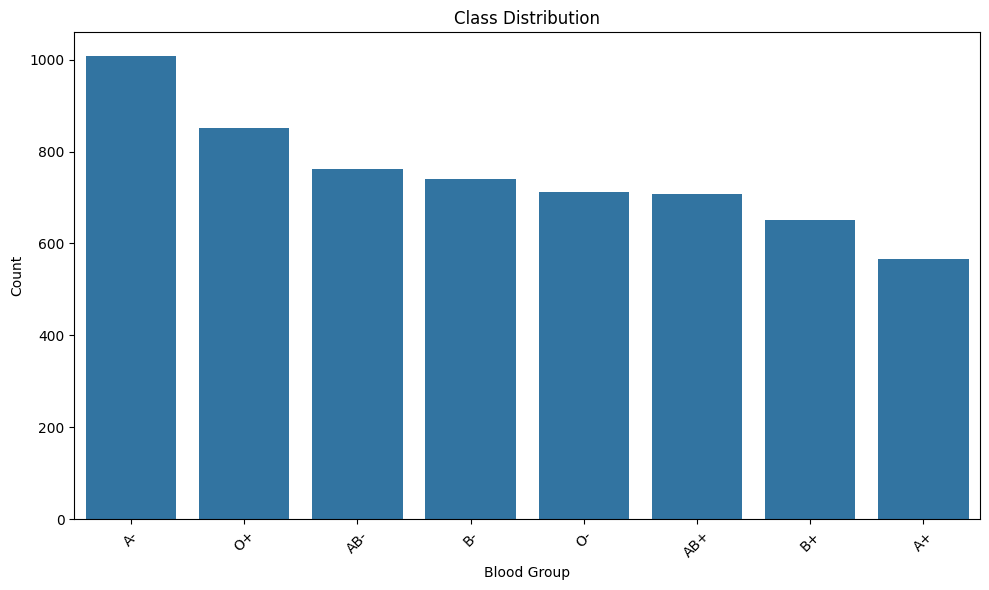

Label
A-     1009
O+      852
AB-     761
B-      741
O-      712
AB+     708
B+      652
A+      565
Name: count, dtype: int64


In [22]:
counts = data.Label.value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.xlabel("Blood Group")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(counts)

In [23]:
train, test = train_test_split(data, test_size=0.20, random_state=42, stratify=data['Label'])

classes = sorted(train['Label'].unique())
class_to_index = {c: i for i, c in enumerate(classes)}
index_to_class = {i: c for c, i in class_to_index.items()}

print(f"Classes: {classes}")
print(f"Train samples: {len(train)}")
print(f"Test samples: {len(test)}")

# Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train.Label),
    y=train.Label
)
class_weights = dict(zip(classes, class_weights))
class_weights = {class_to_index[k]: v for k, v in class_weights.items()}
print(f"Class weights: {class_weights}")

Classes: ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
Train samples: 4800
Test samples: 1200
Class weights: {0: np.float64(1.3274336283185841), 1: np.float64(0.7434944237918215), 2: np.float64(1.0600706713780919), 3: np.float64(0.9852216748768473), 4: np.float64(1.1494252873563218), 5: np.float64(1.0118043844856661), 6: np.float64(0.8810572687224669), 7: np.float64(1.0526315789473684)}


In [24]:
train_transform = A.Compose([
    A.Rotate(limit=30, p=0.7),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=30, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.4, contrast_limit=0.4, p=0.7),
    A.GaussNoise(std_range=(0.05, 0.15), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.4),
    A.RandomResizedCrop(size=(299, 299), scale=(0.8, 1.0), p=0.5),
    A.MotionBlur(blur_limit=7, p=0.3),
    A.GridDistortion(p=0.3),
])

# No augmentation for test
test_transform = None

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-2129/2502834281.py:8: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=32, max_width=32, p=0.4),


In [25]:
class AlbumentationsDataGenerator(Sequence):
    def __init__(self, dataframe, batch_size, target_size, transform=None, shuffle=True):
        self.dataframe = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.transform = transform
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.dataframe))
        self.classes = classes
        self.class_to_index = class_to_index
        self.on_epoch_end()

    def __len__(self):
        return math.ceil(len(self.dataframe) / self.batch_size)

    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        images = []
        labels = []

        for i in batch_indexes:
            img_path = self.dataframe.loc[i, 'Filepath']
            label = self.dataframe.loc[i, 'Label']

            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, self.target_size)

            if self.transform:
                augmented = self.transform(image=image)
                image = augmented['image']

            image = image.astype('float32')
            image = preprocess_input(image)

            images.append(image)
            labels.append(self.class_to_index[label])

        return np.array(images), to_categorical(labels, num_classes=len(self.classes))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

In [26]:
TARGET_SIZE = (299, 299)
BATCH_SIZE = 16

train_gen = AlbumentationsDataGenerator(
    train,
    batch_size=BATCH_SIZE,
    target_size=TARGET_SIZE,
    transform=train_transform
)

test_gen = AlbumentationsDataGenerator(
    test,
    batch_size=BATCH_SIZE,
    target_size=TARGET_SIZE,
    transform=None,
    shuffle=False
)

print(f"Train batches: {len(train_gen)}")
print(f"Test batches: {len(test_gen)}")

Train batches: 300
Test batches: 75


In [27]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)

        # Calculate cross entropy
        cross_entropy = -y_true * tf.math.log(y_pred)

        # Calculate weight
        weight = alpha * y_true * tf.pow(1 - y_pred, gamma)

        # Calculate focal loss
        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))
    return loss

In [28]:
# Build base model with larger input
base_model = ResNet50(
    input_shape=(299, 299, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

# Freeze all layers initially
base_model.trainable = False

# Build custom classifier with residual connections
inputs = base_model.input
x = base_model.output

# Main path
x = Dense(1024, activation='relu', name='dense_1024')(x)
x = BatchNormalization(name='bn_1024')(x)
x = Dropout(0.5, name='dropout_1024')(x)

x = Dense(512, activation='relu', name='dense_512')(x)
x = BatchNormalization(name='bn_512')(x)
x = Dropout(0.4, name='dropout_512')(x)

x = Dense(256, activation='relu', name='dense_256_main')(x)
x = BatchNormalization(name='bn_256_main')(x)
x = Dropout(0.3, name='dropout_256_main')(x)

# Skip connection from base
skip = Dense(256, activation='relu', name='dense_skip')(base_model.output)
skip = BatchNormalization(name='bn_skip')(skip)

# Merge with residual
x = Add(name='residual_add')([x, skip])

# Output layer
outputs = Dense(len(classes), activation='softmax', name='predictions')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile with focal loss
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 305, 305,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 150, 150,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 150, 150,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 150, 150,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 152, 152,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 75, 75,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 75, 75,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 75, 75,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 75, 75,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 75, 75,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 75, 75,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 75, 75,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 75, 75,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 75, 75,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 75, 75,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 75, 75,    │      1,024 │ conv2_block1_3_c

 Total params: 26,876,808 (102.53 MB)

 Trainable params: 3,285,000 (12.53 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [29]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_resnet_phase1.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# Train Phase 1
history_phase1 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=30,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1863 - loss: 0.6569
Epoch 1: val_accuracy improved from -inf to 0.30833, saving model to /content/drive/MyDrive/best_resnet_phase1.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 77s 188ms/step - accuracy: 0.1865 - loss: 0.6566 - val_accuracy: 0.3083 - val_loss: 0.3922 - learning_rate: 1.0000e-04
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2962 - loss: 0.4738
Epoch 2: val_accuracy improved from 0.30833 to 0.35083, saving model to /content/drive/MyDrive/best_resnet_phase1.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 62s 206ms/step - accuracy: 0.2962 - loss: 0.4738 - val_accuracy: 0.3508 - val_loss: 0.3177 - learning_rate: 1.0000e-04
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.3130 - loss: 0.4414
Epoch 3: val_accuracy did not improve from 0.35083
300/300 ━━━━━━━━━━━━━━━━━━━━ 73s 176ms/step - accuracy: 0.3130 - loss: 0.4414 - val_accuracy: 0.3250 - val_loss: 0.3304 - learning_rate: 1.0000e-04
Epoc

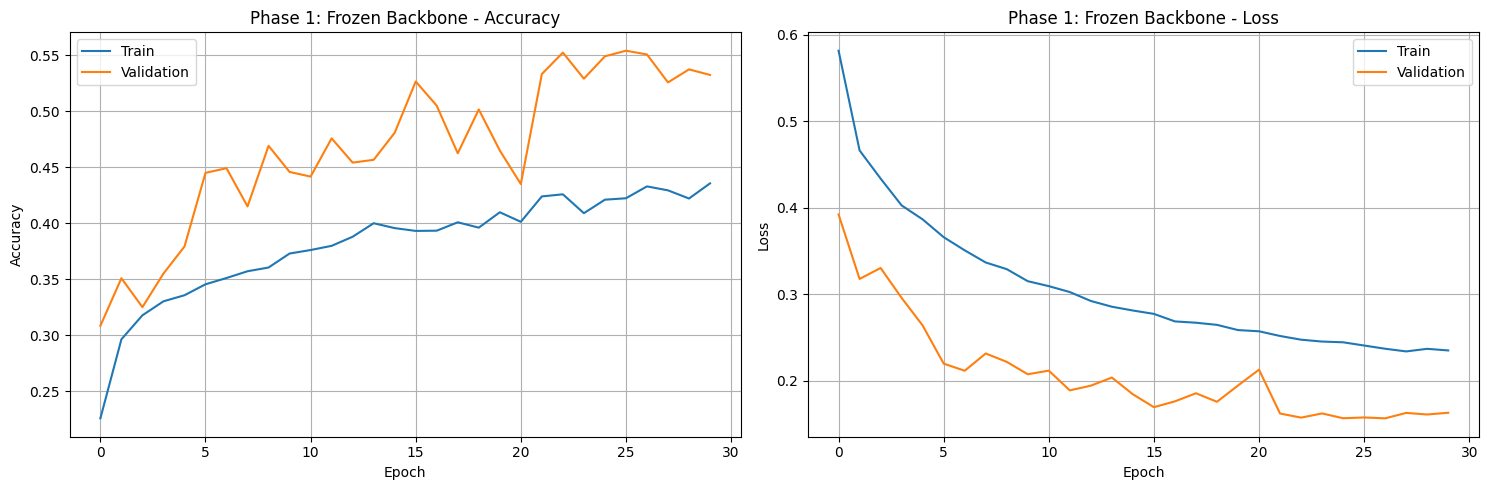

In [30]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Loss
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Phase 1: Frozen Backbone')

In [32]:
# Unfreeze last 100 layers
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

print(f"Trainable layers: {sum([l.trainable for l in base_model.layers])}")
print(f"Total layers: {len(base_model.layers)}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)

# Callbacks for phase 2
checkpoint_phase2 = ModelCheckpoint(
    "/content/drive/MyDrive/best_resnet_phase2.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_phase2 = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-8,
    verbose=1
)

# Train Phase 2
history_phase2 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stop_phase2, reduce_lr_phase2, checkpoint_phase2],
    verbose=1
)

Trainable layers: 100
Total layers: 176
Epoch 1/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4549 - loss: 0.2335
Epoch 1: val_accuracy improved from -inf to 0.61083, saving model to /content/drive/MyDrive/best_resnet_phase2.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 241ms/step - accuracy: 0.4549 - loss: 0.2335 - val_accuracy: 0.6108 - val_loss: 0.1288 - learning_rate: 1.0000e-05
Epoch 2/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.4585 - loss: 0.2264
Epoch 2: val_accuracy improved from 0.61083 to 0.64917, saving model to /content/drive/MyDrive/best_resnet_phase2.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 69s 229ms/step - accuracy: 0.4585 - loss: 0.2264 - val_accuracy: 0.6492 - val_loss: 0.1179 - learning_rate: 1.0000e-05
Epoch 3/20
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - accuracy: 0.4914 - loss: 0.2096
Epoch 3: val_accuracy improved from 0.64917 to 0.68583, saving model to /content/drive/MyDrive/best_resnet_phase2.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 68s 227ms/ste

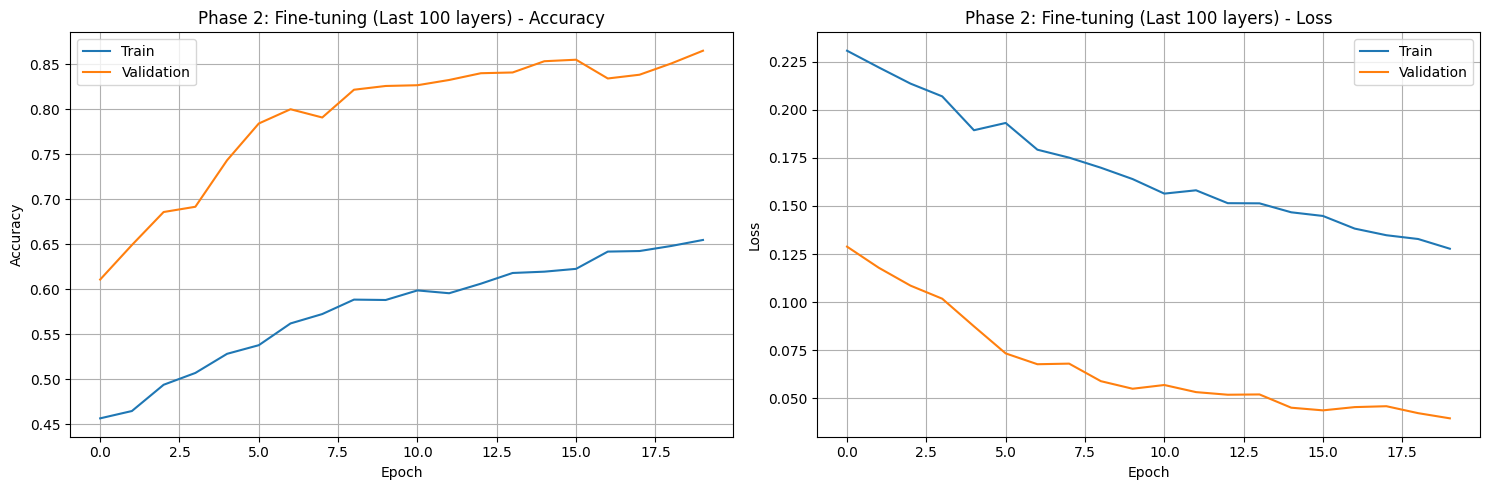

In [33]:
plot_history(history_phase2, 'Phase 2: Fine-tuning (Last 100 layers)')

In [35]:
# Unfreeze last 150 layers
for layer in base_model.layers[:-150]:
    layer.trainable = False

print(f"Trainable layers now: {sum([l.trainable for l in base_model.layers])}")

# Even lower learning rate
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)

# Callbacks for phase 3
checkpoint_phase3 = ModelCheckpoint(
    "/content/drive/MyDrive/best_resnet_phase3.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_phase3 = EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-9,
    verbose=1
)

# Train Phase 3
history_phase3 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=[early_stop_phase3, reduce_lr_phase3, checkpoint_phase3],
    verbose=1
)

Trainable layers now: 100
Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.6617 - loss: 0.1274
Epoch 1: val_accuracy improved from -inf to 0.86833, saving model to /content/drive/MyDrive/best_resnet_phase3.keras
300/300 ━━━━━━━━━━━━━━━━━━━━ 113s 248ms/step - accuracy: 0.6617 - loss: 0.1274 - val_accuracy: 0.8683 - val_loss: 0.0374 - learning_rate: 5.0000e-06
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - accuracy: 0.6811 - loss: 0.1120
Epoch 2: val_accuracy did not improve from 0.86833
300/300 ━━━━━━━━━━━━━━━━━━━━ 67s 224ms/step - accuracy: 0.6811 - loss: 0.1120 - val_accuracy: 0.8608 - val_loss: 0.0398 - learning_rate: 5.0000e-06
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6810 - loss: 0.1157
Epoch 3: val_accuracy did not improve from 0.86833
300/300 ━━━━━━━━━━━━━━━━━━━━ 64s 214ms/step - accuracy: 0.6809 - loss: 0.1157 - val_accuracy: 0.8600 - val_loss: 0.0414 - learning_rate: 5.0000e-06
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 192

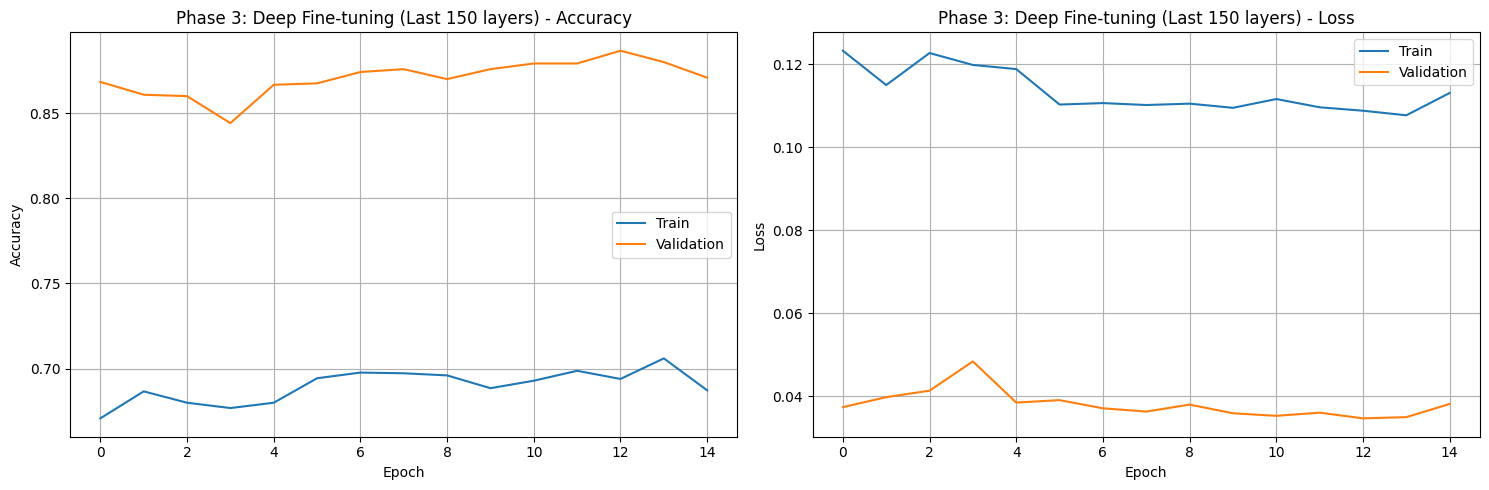

In [36]:
plot_history(history_phase3, 'Phase 3: Deep Fine-tuning (Last 150 layers)')

In [37]:
def predict_with_tta(model, generator, n_augmentations=5):
    """
    Test-Time Augmentation for better predictions
    """
    # Original predictions
    predictions = [model.predict(generator, verbose=1)]

    # Create augmented test generator
    tta_transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.Rotate(limit=10, p=0.5),
    ])

    # Multiple augmented predictions
    for i in range(n_augmentations - 1):
        aug_gen = AlbumentationsDataGenerator(
            test,
            batch_size=BATCH_SIZE,
            target_size=TARGET_SIZE,
            transform=tta_transform,
            shuffle=False
        )
        pred = model.predict(aug_gen, verbose=1)
        predictions.append(pred)

    # Average predictions
    final_pred = np.mean(predictions, axis=0)
    return final_pred

print("TTA function defined")

TTA function defined


In [38]:
# Get true labels
true_classes = []
for i in range(len(test_gen)):
    _, y = test_gen[i]
    true_classes.extend(np.argmax(y, axis=1))
true_classes = np.array(true_classes)

# Standard prediction (without TTA)
print("=== Standard Evaluation ===")
pred_standard = model.predict(test_gen)
pred_classes_standard = np.argmax(pred_standard, axis=1)

# Trim to match lengths
true_classes_trimmed = true_classes[:len(pred_classes_standard)]

accuracy_standard = np.mean(pred_classes_standard == true_classes_trimmed) * 100
print(f"Test Accuracy (Standard): {accuracy_standard:.2f}%")
print("\nClassification Report (Standard):")
print(classification_report(
    true_classes_trimmed,
    pred_classes_standard,
    target_names=classes,
    digits=3
))

=== Standard Evaluation ===
75/75 ━━━━━━━━━━━━━━━━━━━━ 13s 84ms/step
Test Accuracy (Standard): 88.67%

Classification Report (Standard):
              precision    recall  f1-score   support

          A+      0.925     0.876     0.900       113
          A-      0.929     0.906     0.917       202
         AB+      0.940     0.775     0.849       142
         AB-      0.861     0.855     0.858       152
          B+      0.881     0.915     0.898       130
          B-      0.903     0.939     0.921       148
          O+      0.894     0.889     0.891       171
          O-      0.781     0.930     0.849       142

    accuracy                          0.887      1200
   macro avg      0.889     0.886     0.885      1200
weighted avg      0.890     0.887     0.887      1200



In [39]:
# Prediction with TTA (takes longer but more accurate)
print("=== TTA Evaluation (this may take time) ===")
pred_tta = predict_with_tta(model, test_gen, n_augmentations=5)
pred_classes_tta = np.argmax(pred_tta, axis=1)

# Trim to match
pred_classes_tta = pred_classes_tta[:len(true_classes_trimmed)]

accuracy_tta = np.mean(pred_classes_tta == true_classes_trimmed) * 100
print(f"\nTest Accuracy (With TTA): {accuracy_tta:.2f}%")
print("\nClassification Report (TTA):")
print(classification_report(
    true_classes_trimmed,
    pred_classes_tta,
    target_names=classes,
    digits=3
))

=== TTA Evaluation (this may take time) ===
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 7s 92ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 6s 85ms/step

Test Accuracy (With TTA): 89.00%

Classification Report (TTA):
              precision    recall  f1-score   support

          A+      0.911     0.903     0.907       113
          A-      0.939     0.916     0.927       202
         AB+      0.915     0.838     0.875       142
         AB-      0.848     0.842     0.845       152
          B+      0.857     0.923     0.889       130
          B-      0.914     0.939     0.927       148
          O+      0.923     0.836     0.877       171
          O-      0.810     0.930     0.866       142

    accuracy                          0.890      1200
   macro avg      0.890     0.891     0.889      1200
weighted avg      0.892     0.890     0.890      1200



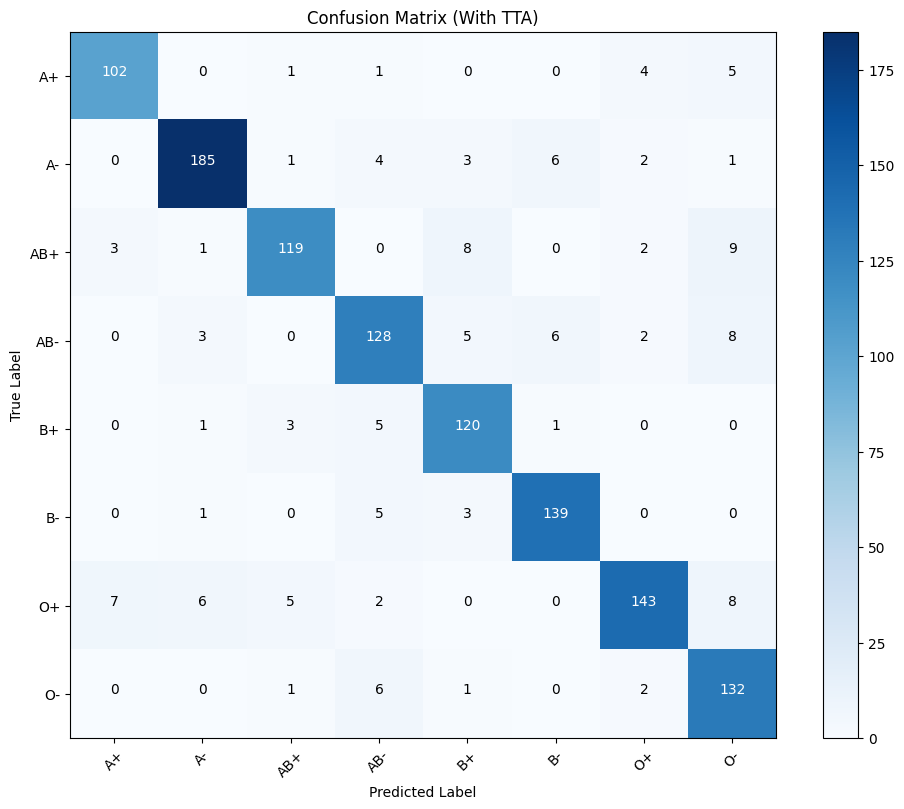

In [40]:
# Plot confusion matrix
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add text annotations
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                horizontalalignment="center",
                color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Plot for TTA predictions
plot_confusion_matrix(
    true_classes_trimmed,
    pred_classes_tta,
    classes,
    title='Confusion Matrix (With TTA)'
)

In [41]:
# Save the final model
final_model_path = "/content/drive/MyDrive/resnet50_blood_group_final.keras"
model.save(final_model_path)
print(f"Model saved to: {final_model_path}")

# Also save as HDF5 format (backup)
h5_model_path = "/content/drive/MyDrive/resnet50_blood_group_final.h5"
model.save(h5_model_path)
print(f"Model also saved as HDF5: {h5_model_path}")

# Save best weights separately
weights_path = "/content/drive/MyDrive/resnet50_blood_group_weights.weights.h5"
model.save_weights(weights_path)
print(f"Weights saved to: {weights_path}")

Model saved to: /content/drive/MyDrive/resnet50_blood_group_final.keras
Model also saved as HDF5: /content/drive/MyDrive/resnet50_blood_group_final.h5
Weights saved to: /content/drive/MyDrive/resnet50_blood_group_weights.weights.h5


In [ ]:
print("=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

print(f"\nOriginal VGG Accuracy: 87%")
print(f"Standard ResNet Accuracy: {accuracy_standard:.2f}%")
print(f"TTA ResNet Accuracy: {accuracy_tta:.2f}%")

improvement = accuracy_tta - 87
if improvement > 0:
    print(f"\n SUCCESS: Beat VGG by {improvement:.2f}%!")
else:
    print(f"\n Gap to VGG: {abs(improvement):.2f}%")

print(f"\nModel Configuration:")
print(f"- Input Size: {TARGET_SIZE}")
print(f"- Batch Size: {BATCH_SIZE}")
print(f"- Focal Loss: gamma=2.0")
print(f"- Augmentations: Enhanced (rotation, noise, crop, etc.)")
print(f"- Training Phases: 3 (Frozen → 100 layers → 150 layers)")
print(f"- TTA: Enabled (5 augmentations)")

print(f"\nClass-wise Performance (TTA):")
report = classification_report(
    true_classes_trimmed,
    pred_classes_tta,
    target_names=classes,
    output_dict=True
)
for cls in classes:
    print(f"  {cls}: F1={report[cls]['f1-score']:.3f}, Precision={report[cls]['precision']:.3f}, Recall={report[cls]['recall']:.3f}")

TRAINING SUMMARY

Original VGG Accuracy: 87%
Standard ResNet Accuracy: 88.67%
TTA ResNet Accuracy: 89.00%

✅ SUCCESS: Beat VGG by 2.00%!

Model Configuration:
- Input Size: (299, 299)
- Batch Size: 16
- Focal Loss: gamma=2.0
- Augmentations: Enhanced (rotation, noise, crop, etc.)
- Training Phases: 3 (Frozen → 100 layers → 150 layers)
- TTA: Enabled (5 augmentations)

Class-wise Performance (TTA):
  A+: F1=0.907, Precision=0.911, Recall=0.903
  A-: F1=0.927, Precision=0.939, Recall=0.916
  AB+: F1=0.875, Precision=0.915, Recall=0.838
  AB-: F1=0.845, Precision=0.848, Recall=0.842
  B+: F1=0.889, Precision=0.857, Recall=0.923
  B-: F1=0.927, Precision=0.914, Recall=0.939
  O+: F1=0.877, Precision=0.923, Recall=0.836
  O-: F1=0.866, Precision=0.810, Recall=0.930


In [ ]:
# Verify saved model can be loaded
print("Verifying saved model...")
loaded_model = tf.keras.models.load_model(
    final_model_path,
    custom_objects={'loss': focal_loss(gamma=2.0)}
)

# Quick test
test_pred = loaded_model.predict(test_gen[:1])
print(f"Model loaded successfully! Output shape: {test_pred.shape}")
print(f"Sample prediction: {test_pred[0]}")